__Классификация аудиоданных.__ 

Евгений Борисов esborisov@sevsu.ru


----

Understand Audio data.   
https://www.geeksforgeeks.org/understand-audio-data/

Классификация аудиофайлов с библиотекой Librosa.     
https://habr.com/ru/companies/otus/articles/741080/

Music Information Retrieval    
https://musicinformationretrieval.com

Understanding Origins and Fusion of Music Genres     
https://shouvikmani.github.io/Million-Song-Dataset-Visualization/index.html

In [3]:
# pip install librosa

## загружаем данные 

George Tzanetakis, Georg Essl, Perry Cook    Automatic Musical Genre Classification Of Audio Signals.   
https://ismir2001.ismir.net/pdf/tzanetakis.pdf   

Raw data is 1.2GB and consists of 1000 audio files(.au) divided into 10 folders for 10 genres equally. I.e Every genre has 100 audio files.

http://opihi.cs.uvic.ca/sound/genres.tar.gz

https://drive.google.com/drive/folders/189jIlfQ-E94eHfKVksbAUSXKX68Ju1GI

https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

In [4]:
data_folder = 'data'

In [5]:
import os
import pandas as pd
from tqdm.cli import tqdm
tqdm.pandas()

In [6]:
files = pd.DataFrame([ 
        { 
            'fpath': f'{data_folder}/genres_original/{genre}/{fname}', 
            'genre': genre, 
        } 
        for genre in os.listdir(f'{data_folder}/genres_original/')
        for fname in os.listdir(f'{data_folder}/genres_original/{genre}')
    ]).reset_index(drop=True)

display( len(files) )
display( files.sample(5) )

1000

,fpath,genre
207,data/genres_original/jazz/jazz.00026.wav,jazz
272,data/genres_original/jazz/jazz.00071.wav,jazz
357,data/genres_original/country/country.00030.wav,country
935,data/genres_original/classical/classical.00065...,classical
244,data/genres_original/jazz/jazz.00037.wav,jazz


In [7]:
files.groupby('genre').count()

,fpath
genre,
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100


# признаки в аудиоданных

In [8]:
import numpy as np
import numpy.random as rng
import matplotlib.pyplot as plt

In [9]:
# from pydub import AudioSegment
from IPython.display import Audio

In [10]:
import librosa as lrs
from librosa.display import waveshow
from librosa.display import specshow
from librosa import feature

In [11]:
# lrs.version.show_versions()

In [12]:
files

,fpath,genre
0,data/genres_original/reggae/reggae.00049.wav,reggae
1,data/genres_original/reggae/reggae.00037.wav,reggae
2,data/genres_original/reggae/reggae.00040.wav,reggae
3,data/genres_original/reggae/reggae.00057.wav,reggae
4,data/genres_original/reggae/reggae.00036.wav,reggae
...,...,...
995,data/genres_original/classical/classical.00001...,classical
996,data/genres_original/classical/classical.00080...,classical
997,data/genres_original/classical/classical.00057...,classical
998,data/genres_original/classical/classical.00086...,classical


In [43]:
# pip install ipywidgets

In [46]:
fpath = files.sample()['fpath'].values[0]
display(fpath)

data, rate = lrs.load(fpath)
display(data.shape, rate)


print( f'Duration: { lrs.get_duration(y=data,sr=rate):.2f} sec' )

print(f'Sample Rate: {rate}')

# Compute the amplitude range
amplitude_range = np.max(data) - np.min(data)
print(f'Amplitude Range: {amplitude_range}')

# Get the bit depth from the audio data
bit_depth = data.dtype.itemsize
# printing values
print(f'Bit Depth: {bit_depth} bits')


display( Audio(data=data,rate=rate,autoplay=False) )

'data/genres_original/disco/disco.00038.wav'

(661794,)

22050

Duration: 30.01 sec
Sample Rate: 22050
Amplitude Range: 1.577728271484375
Bit Depth: 4 bits


Text(0.5, 1.0, 'data/genres_original/disco/disco.00038.wav')

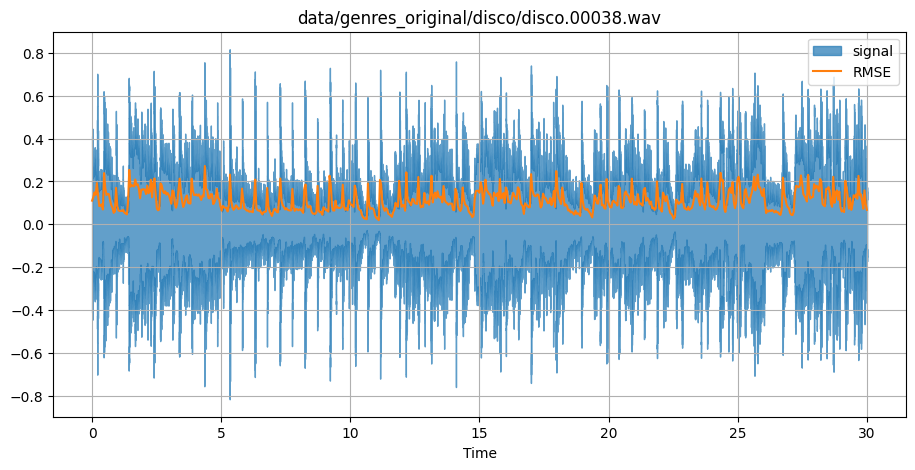

In [47]:
# Root-mean square energy

data_rms = feature.rms(y=data, frame_length=1024, hop_length=1024)[0]
t = lrs.times_like(data_rms, hop_length=1024, sr=rate)

fig,ax = plt.subplots(figsize=(11, 5))
waveshow(y=data, sr=rate, alpha=.7, ax=ax, label='signal')
ax.plot( t, data_rms, label='RMSE' )
ax.grid()
ax.legend()
ax.set_title(fpath)

In [ ]:
# feature.zero_crossing_rate(data).shape
# # zc = lrs.zero_crossings(data)

# zrate = feature.zero_crossing_rate(data)

# fig,ax = plt.subplots(figsize=(11, 5))
# ax.semilogy(zrate.T, label='Fraction')
# #ax.plot(zrate.T, label='Fraction')
# ax.set_ylabel('Fraction per Frame')
# ax.grid()
# ax.legend()

# data_rms = feature.rms(y=data, frame_length=1024, hop_length=1024)[0]
# feature.rms(y=data).shape

# feature.spectral_centroid(y=data, sr=rate).shape

# feature.spectral_rolloff(y=data, sr=rate)

# feature.chroma_stft(y=data, sr=rate).shape

# feature.spectral_bandwidth(y=data, sr=rate).std()

# feature.tonnetz(y=data, sr=rate).shape

# plt.plot( data, alpha=0.7 )
# plt.plot( lrs.effects.harmonic(data) )

# C = np.abs(lrs.cqt(y=data, sr=rate, fmin=lrs.note_to_hz('A1')))
# freqs = lrs.cqt_frequencies(C.shape[0],fmin=lrs.note_to_hz('A1'))
# perceptual_CQT = librosa.perceptual_weighting(C**2,freqs, ref=np.max)

In [52]:
tempo, beat_frames = lrs.beat.beat_track(y=data, sr=rate)
print(f'Estimated tempo: {tempo[0]:.2f} beats per minute')

Estimated tempo: 123.05 beats per minute


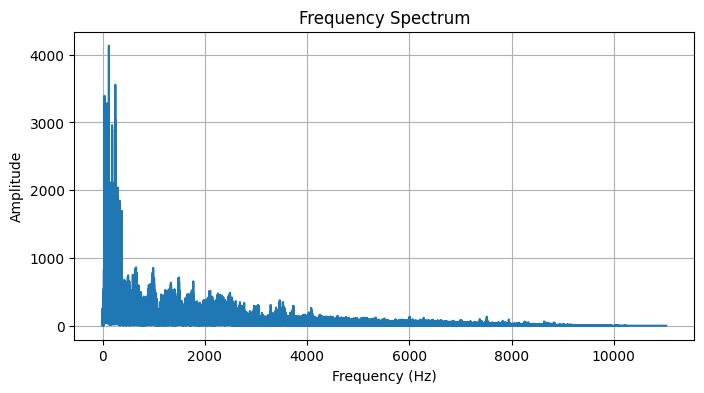

In [18]:
from scipy.fft import fft

# Compute the FFT of the waveform
spectrum = fft(data)
 
# Frequency bins
frequencies = np.fft.fftfreq(len(spectrum), 1 / rate)
 
# Plot the frequency spectrum
plt.figure(figsize=(8, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(spectrum[:len(spectrum)//2]))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Frequency Spectrum')
plt.grid(True)
plt.show()


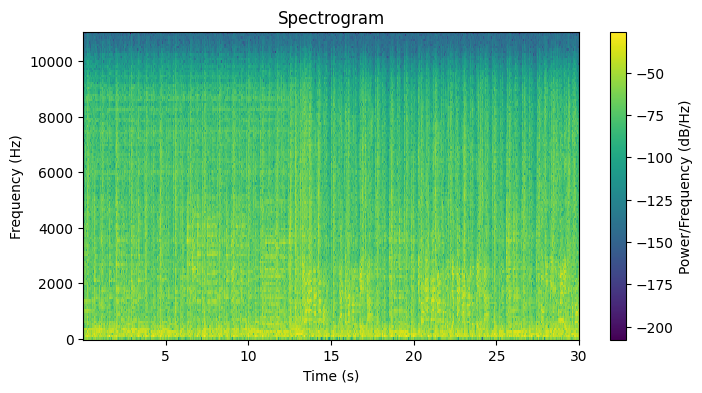

In [19]:
# Compute the spectrogram
from scipy.signal import spectrogram
    
# Small constant to avoid division by zero(if any)
epsilon = 1e-40 
f, t, Sxx = spectrogram(data, fs=rate)
 
# Plot the spectrogram with the constant added to Sxx
plt.figure(figsize=(8, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx + epsilon))
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Spectrogram')
plt.show()


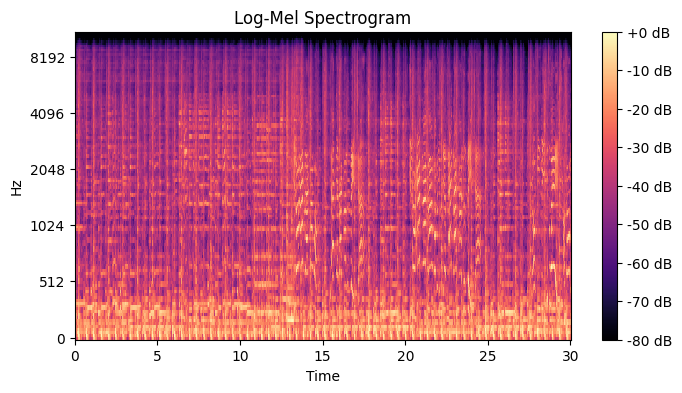

In [20]:
# visualizing log-mel spectrogram
def compute_logmel_spectrogram(y, sr, n_mels=128, hop_length=512):
    mel_spectrogram = feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    logmel_spectrogram = lrs.power_to_db(mel_spectrogram, ref=np.max)
    return logmel_spectrogram

# Compute log-mel spectrogram
logmel_spectrogram = compute_logmel_spectrogram(data, sr=rate)
 
# Display the log-mel spectrogram
plt.figure(figsize=(8, 4))
specshow(logmel_spectrogram, sr=rate, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.show()

# формируем датасет

In [21]:
# %%time

# def music_features(fpath):
#     data, rate = lrs.load(fpath)
        
#     tempo, _ = lrs.beat.beat_track(y=data, sr=rate)
#     zc = feature.zero_crossing_rate(data)
#     rms = feature.rms(y=data)
#     cent = feature.spectral_centroid(y=data, sr=rate)
#     rolloff = feature.spectral_rolloff(y=data, sr=rate)
#     cstft = feature.chroma_stft(y=data, sr=rate)
#     sbandwidth = feature.spectral_bandwidth(y=data, sr=rate)
#     # mfcc = [ feature.mfcc(y=data,sr=rate,n_mels=n) for n in range(10,21,5) ]
#     mfcc = [ feature.mfcc(y=data,sr=rate) ]
#     tonnetz = feature.tonnetz(y=data, sr=rate)
#     # harmonic = lrs.effects.harmonic(data)
    
#     return np.hstack([
#         zc.mean(),zc.std(),
#         rms.mean(),rms.std(),
#         tempo,
#         cent.mean(),cent.std(),
#         rolloff.mean(),rolloff.std(),
#         cstft.mean(axis=1),cstft.std(axis=1),
#         sbandwidth.mean(axis=1),sbandwidth.std(axis=1),
#         tonnetz.mean(axis=1),tonnetz.std(axis=1),
#         # harmonic.mean(),harmonic.std(),
#         ] 
#         + [ m.mean(axis=1) for m in mfcc ] + [ m.std(axis=1) for m in mfcc ]
        
#     )

# x = np.vstack(
#         files.apply(
#             lambda r: os.path.join( *[ data_folder ] + r[['genre','file']].tolist() ),
#             axis=1
#         ).progress_apply(music_features)
#     )

# display(x.shape)

In [22]:
# labels = { g:n for n,g in enumerate(sorted(set(files['genre']))) } 
# target = files['genre'].map(labels).values

----

In [23]:
import pandas as pd

df = pd.read_csv( f'{data_folder}/features_3_sec.csv.gz').convert_dtypes()
display( len(df) )
display( df.sample(5) )

9990

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
5491,jazz.00049.9.wav,66149,0.255883,0.095145,0.12939,0.002281,1490.18801,160951.150524,2379.371196,113256.848017,...,29.065321,-5.737813,31.33534,-5.750228,32.484661,0.865496,56.514755,9.901802,111.076035,jazz
3966,disco.00097.2.wav,66149,0.422916,0.08633,0.104219,0.002198,2708.395105,213991.131232,2634.516428,62964.717468,...,25.263233,-4.64711,42.05344,8.913401,66.910378,-7.427171,30.819523,3.24772,34.948303,disco
1394,classical.00039.4.wav,66149,0.25822,0.087516,0.011296,0.000081,1425.09943,142993.080857,1567.50926,84543.539594,...,43.032337,3.611194,43.997978,0.568452,42.98687,0.535264,93.272224,0.911467,79.127701,classical
2902,country.00090.7.wav,66149,0.357156,0.082176,0.134097,0.002528,1996.164656,501059.134594,2026.628223,123911.613504,...,36.993546,-6.020799,81.08609,2.724616,35.134525,-8.717465,41.779312,-3.677662,36.286201,country
969,blues.00096.9.wav,66149,0.266172,0.098411,0.069295,0.000379,1210.410732,240678.162027,1867.294973,105891.44565,...,64.53891,-11.795057,36.778931,0.396822,52.245659,-2.59037,53.196396,-9.311045,102.718903,blues


In [24]:
df.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

In [25]:
cols_features = [
    'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
    'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
    'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
    'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
    'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
    'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
    'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
    'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
    'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
    'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
    'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
    'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
    'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
]

# визуализация данных

<function matplotlib.pyplot.show(close=None, block=None)>

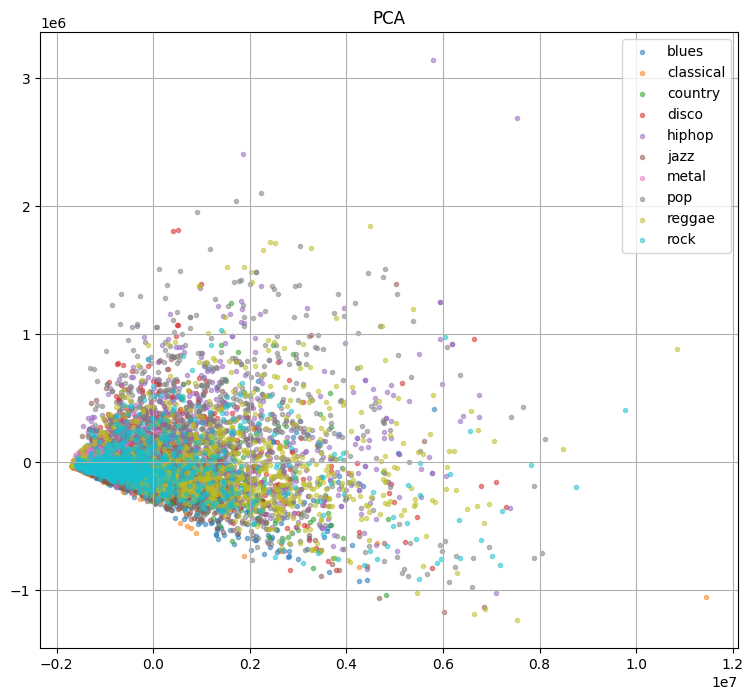

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df[['pca_x2_0','pca_x2_1']] = PCA(n_components=2).fit_transform(df[cols_features].values)

fig, ax = plt.subplots(figsize=(9,8))
for label, group in df.groupby('label'):
    ax.scatter(group['pca_x2_0'], group['pca_x2_1'], label=label, s=9, alpha=0.5 ) 
ax.legend()
ax.set_title('PCA')
ax.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

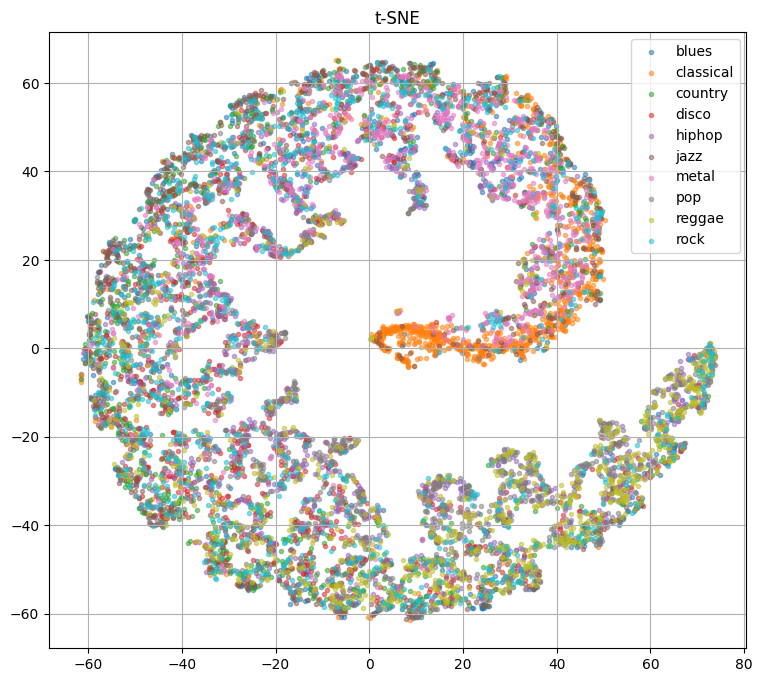

In [27]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

df[['tsne_x2_0','tsne_x2_1']] = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=64).fit_transform(df[cols_features].values)

fig, ax = plt.subplots(figsize=(9,8))
for label, group in df.groupby('label'):
    ax.scatter(group['tsne_x2_0'], group['tsne_x2_1'], label=label, s=9, alpha=0.5 ) 
ax.legend()
ax.set_title('t-SNE')
ax.grid()
plt.show


# обучаем классификатор

In [28]:
df['target'] = pd.Categorical( df['label'] ).codes
x = df[cols_features].values
target = df['target'].values
display( x.shape,target.shape )

(9990, 57)

(9990,)

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, target_train, target_test = train_test_split(x,target,test_size=0.3)
display( x_train.shape, target_train.shape, x_test.shape, target_test.shape )

(6993, 57)

(6993,)

(2997, 57)

(2997,)

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
length,9990.0,66149.0,0.0,66149.0,66149.0,66149.0,66149.0,66149.0
chroma_stft_mean,9990.0,0.379534,0.090466,0.107108,0.315698,0.384741,0.442443,0.749481
chroma_stft_var,9990.0,0.084876,0.009637,0.015345,0.079833,0.085108,0.091092,0.120964
rms_mean,9990.0,0.130859,0.068545,0.000953,0.083782,0.121253,0.176328,0.442567
rms_var,9990.0,0.002676,0.003586,0.0,0.000615,0.001491,0.003131,0.032615
...,...,...,...,...,...,...,...,...
pca_x2_0,9990.0,-0.0,1531447.072208,-1683201.417449,-1102963.677929,-485048.603586,648738.510598,11446303.787102
pca_x2_1,9990.0,0.0,265560.979163,-1232334.839398,-105339.704478,-34809.269452,47965.831309,3138310.779896
tsne_x2_0,9990.0,0.093261,34.924835,-61.572826,-30.200644,-1.852789,29.746706,73.712814
tsne_x2_1,9990.0,0.099608,35.888103,-61.446842,-31.87717,0.05733,33.388967,65.140152


In [31]:
# from sklearn.preprocessing import StandardScaler as Scaler
from  sklearn.preprocessing import RobustScaler as Scaler
scaler = Scaler().fit(x_train)
x_train_ = scaler.transform(x_train)
x_test_ = scaler.transform(x_test)

---

In [32]:
# pip install xgboost
# pip install xgboost-cpu

In [33]:
from xgboost import XGBClassifier
model = XGBClassifier(
        n_estimators=1024, 
        learning_rate=0.05, 
        # device='cuda:1'
        device='cpu'
    ).fit(x_train_,target_train)

In [34]:
# from sklearn.ensemble import RandomForestClassifier
# model = RandomForestClassifier().fit(x_train_,target_train)

In [35]:
# from sklearn.linear_model import SGDClassifier
# model = SGDClassifier().fit(x_train_,target_train)

In [36]:
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression().fit(x_train_,target_train)

In [37]:
# from sklearn.neural_network import MLPClassifier
# model = MLPClassifier(
#         hidden_layer_sizes=(1024*2,10)
#         #solver='lbfgs', alpha=1e-5, , random_state=1
#     ).fit(x_train_,target_train)

In [38]:
o_train = model.predict(x_train_)
o_test = model.predict(x_test_)

# результаты

In [39]:
from sklearn.metrics import accuracy_score

# доля правильных ответов на учебном наборе
display( accuracy_score(target_train,o_train) )

# доля правильных ответов на тестовом наборе
display(  accuracy_score(target_test,o_test) )

0.9991419991419992

0.9052385719052386

In [40]:
from sklearn.metrics import classification_report
labels = sorted(set(df['label']))
print( classification_report( target_test, o_test, target_names=labels) )

              precision    recall  f1-score   support

       blues       0.91      0.91      0.91       286
   classical       0.94      0.95      0.94       287
     country       0.87      0.90      0.88       320
       disco       0.86      0.91      0.88       286
      hiphop       0.92      0.91      0.91       295
        jazz       0.91      0.92      0.91       307
       metal       0.95      0.96      0.95       278
         pop       0.94      0.88      0.91       318
      reggae       0.89      0.89      0.89       315
        rock       0.87      0.86      0.86       305

    accuracy                           0.91      2997
   macro avg       0.91      0.91      0.91      2997
weighted avg       0.91      0.91      0.91      2997



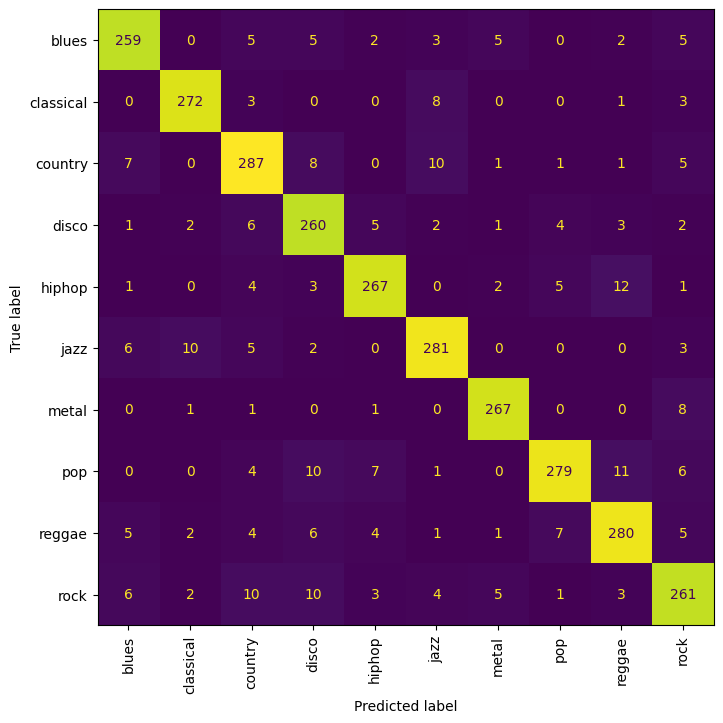

In [41]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig,ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(target_test,o_test), 
        display_labels=labels,
    ).plot(
        ax=ax, 
        xticks_rotation='vertical', 
        include_values=True, 
        cmap='viridis',  
        colorbar=False,
    )
# plt.show()